# Setup and Imports

In [22]:
import importlib
import src.data_loader
import src.heuristic
import src.gnn_utils
import src.gnn_model

importlib.reload(src.data_loader)
importlib.reload(src.heuristic)
importlib.reload(src.gnn_utils)
importlib.reload(src.gnn_model)

<module 'src.gnn_model' from '/Users/szymonzalewski/Documents/project-milestone-p2-group2/src/gnn_model.py'>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import os

from src.data_loader import (
    load_wikispeedia_file,
    load_shortest_path_matrix,
    get_article_text,
    get_article_html,
    find_absolute_link_position_from_df
)
from src.feature_extractor import FeatureExtractor, EMBEDDING_DIM
from src.evaluation import calculate_mrr
from src.html_processor import HtmlProcessor
from pathlib import Path
from src.heuristic import (
    expand_paths_to_steps,
    compute_mrr_next_link
)
import random
from src.gnn_utils import *
from src.gnn_model import *
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load .tsv and .txt files

In [3]:
articles_df = load_wikispeedia_file(
    "articles.tsv",
    columns=["article_name"]
)
articles_df["article_id"] = articles_df["article_name"]

print("Articles:", articles_df.shape)
display(articles_df.head())

categories_df = load_wikispeedia_file(
    "categories.tsv",
    columns=["article", "category"]
)
print("Categories:", categories_df.shape, "\n")
display(categories_df.head())

links_df = load_wikispeedia_file(
    "links.tsv",
    columns=["source", "target"]
)
print("Links:", links_df.shape)
display(links_df.head())

paths_finished_df = load_wikispeedia_file(
    "paths_finished.tsv",
    columns=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
)
print("Finished paths:", paths_finished_df.shape)
display(paths_finished_df.head())

paths_unfinished_df = load_wikispeedia_file(
    "paths_unfinished.tsv",
    columns=["session_id", "timestamp", "session_time", "path", "rating", "type"]
)
print("Unfinished paths:", paths_unfinished_df.shape)
display(paths_unfinished_df.head())

dist_matrix = load_shortest_path_matrix()
print(dist_matrix.shape)

Loading: ./data/wikispeedia_paths-and-graph/articles.tsv
Articles: (4604, 2)


,article_name,article_id
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin
1,Åland,Åland
2,Édouard_Manet,Édouard_Manet
3,Éire,Éire
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts


Loading: ./data/wikispeedia_paths-and-graph/categories.tsv
Categories: (5204, 2) 



,article,category
0,Áedán_mac_Gabráin,subject.History.British_History.British_Histor...
1,Áedán_mac_Gabráin,subject.People.Historical_figures
2,Åland,subject.Countries
3,Åland,subject.Geography.European_Geography.European_...
4,Édouard_Manet,subject.People.Artists


Loading: ./data/wikispeedia_paths-and-graph/links.tsv
Links: (119882, 2)


...

Loading: ./data/wikispeedia_paths-and-graph/paths_finished.tsv
Finished paths: (51318, 5)


,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3


Loading: ./data/wikispeedia_paths-and-graph/paths_unfinished.tsv
Unfinished paths: (24875, 6)


,session_id,timestamp,session_time,path,rating,type
0,2426091a53125110,1297054935,1804,Obi-Wan_Kenobi,Microsoft,timeout
1,26141fd878806294,1297055651,1805,Julius_Caesar,Caracas,timeout
2,2b015fb8181c48f2,1297090819,1818,Malawi;Democracy;Alexander_the_Great,First_Crusade,timeout
3,53a53bc244e08a6a,1297094761,49,Paraguay,Mount_St._Helens,restart
4,53a53bc244e08a6a,1297099105,1808,Paraguay;Bolivia,Mount_St._Helens,timeout


Loading distance matrix...
(4604, 4604)


## Load plain article text & html text into articles dataframe

In [4]:
articles_df["plaintext"] = articles_df["article_name"].apply(lambda x: get_article_text(x))

articles_df["plaintext_length"] = articles_df["plaintext"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

articles_df["html_content"] = articles_df["article_name"].apply(
    lambda x: get_article_html(x)
)

ERROR reading file data/wikispeedia_articles_html/wpcd/wp/d/Directdebit.htm: 'utf-8' codec can't decode byte 0xf4 in position 6145: invalid continuation byte
ERROR reading file data/wikispeedia_articles_html/wpcd/wp/d/Donation.htm: 'utf-8' codec can't decode byte 0xf4 in position 5270: invalid continuation byte
ERROR reading file data/wikispeedia_articles_html/wpcd/wp/f/Friend_Directdebit.htm: 'utf-8' codec can't decode byte 0xa3 in position 1473: invalid start byte
ERROR reading file data/wikispeedia_articles_html/wpcd/wp/s/Sponsorship_Directdebit.htm: 'utf-8' codec can't decode byte 0xa3 in position 1495: invalid start byte
ERROR reading file data/wikispeedia_articles_html/wpcd/wp/w/Wowpurchase.htm: 'utf-8' codec can't decode byte 0xa3 in position 1530: invalid start byte


### Load html text for 5 articles with errors manually 

In [5]:
manual_fixes = {
    "Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/d/Directdebit.htm"
    ,"Donation": "./data/wikispeedia_articles_html/wpcd/wp/d/Donation.htm"
    ,"Friend_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/f/Friend_Directdebit.htm"
    ,"Sponsorship_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/s/Sponsorship_Directdebit.htm"
    ,"Wowpurchase": "./data/wikispeedia_articles_html/wpcd/wp/w/Wowpurchase.htm"
}

for name, path in manual_fixes.items():
    file_path = Path(path)
    try:
        html_text = file_path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        html_text = file_path.read_text(encoding="latin-1")
    articles_df.loc[articles_df["article_name"] == name, "html_content"] = html_text
    print(f"Loaded {name}")

nan_html_content = articles_df[articles_df["html_content"].isna()]
print(f"Amount articles with missing html content: {len(nan_html_content)}")
display(nan_html_content)

Loaded Directdebit
Loaded Donation
Loaded Friend_Directdebit
Loaded Sponsorship_Directdebit
Loaded Wowpurchase
Amount articles with missing html content: 0


,article_name,article_id,plaintext,plaintext_length,html_content


### Add column with length of html text

In [6]:
articles_df["html_length"] = articles_df["html_content"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

display(articles_df.sort_values(by="html_length", ascending=True))

,article_name,article_id,plaintext,plaintext_length,html_content,html_length
4545,Wowpurchase,Wowpurchase,[1x1.gif] [1x1.gi...,871,"<html>\n<head>\n<meta name=""keywords"" content=...",3118
1292,Eastern_Roman_Empire,Eastern_Roman_Empire,#copyright\n\nEastern Roman Empire\n\n2007 ...,1438,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5367
3786,Soil_profile,Soil_profile,#copyright\n\nSoil profile\n\n2007 Schools ...,1577,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5415
297,Apaochi,Apaochi,#copyright\n\nApaochi\n\n2007 Schools Wikip...,1635,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5547
1041,Corn_oil,Corn_oil,#copyright\n\nCorn oil\n\n2007 Schools Wiki...,1834,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5629
...,...,...,...,...,...,...
734,Byzantine_Empire,Byzantine_Empire,#copyright\n\nByzantine Empire\n\n2007 Scho...,108718,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",156402
2108,Indo-Greek_Kingdom,Indo-Greek_Kingdom,#copyright\n\nIndo-Greek Kingdom\n\n2007 Sc...,91676,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",158085
1694,Germany,Germany,#copyright\n\nGermany\n\n2007 Schools Wikip...,69000,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",159886
4542,World_War_II,World_War_II,#copyright\n\nWorld War II\n\n2007 Schools ...,101666,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",160593


## Add two columns for indegree and outdegree of each article

In [7]:
outdegree = links_df["source"].value_counts().rename("outdegree")
indegree = links_df["target"].value_counts().rename("indegree")

articles_df = articles_df.drop(columns=["outdegree", "indegree"], errors="ignore")
articles_df = (
    articles_df
    .merge(outdegree, how="left", left_on="article_name", right_index=True)
    .merge(indegree, how="left", left_on="article_name", right_index=True)
)

articles_df[["outdegree", "indegree"]] = articles_df[["outdegree", "indegree"]].fillna(0).astype(int)
isolated_df = articles_df[(articles_df["outdegree"] == 0) | (articles_df["indegree"] == 0)]

print(f"Amount articles with 0 indegree or outdegree: {len(isolated_df)}")
display(isolated_df)

Amount articles with 0 indegree or outdegree: 474


,article_name,article_id,plaintext,plaintext_length,html_content,html_length,outdegree,indegree
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin,#copyright\n\nÁedán mac Gabráin\n\n2007 Sch...,11612,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",19712,11,0
1,Åland,Åland,#copyright\n\nÅland\n\n2007 Schools Wikiped...,17238,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",38350,19,0
2,Édouard_Manet,Édouard_Manet,#copyright\n\nÉdouard Manet\n\n2007 Schools...,18996,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",36440,20,0
3,Éire,Éire,#copyright\n\nÉire\n\n2007 Schools Wikipedi...,13083,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",19985,8,0
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts,#copyright\n\nÓengus I of the Picts\n\n2007...,12944,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",22697,10,0
...,...,...,...,...,...,...,...,...
4566,Yellowhammer,Yellowhammer,#copyright\n\nYellowhammer\n\n2007 Schools ...,2361,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",10212,13,0
4575,Yotsuya_Kaidan,Yotsuya_Kaidan,#copyright\n\nYotsuya Kaidan\n\n2007 School...,10727,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",17446,2,0
4576,You're_Still_the_One,You're_Still_the_One,#copyright\n\nYou're Still the One\n\n2007 ...,13571,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",28785,2,0
4580,"Yungay,_Peru","Yungay,_Peru","#copyright\n\nYungay, Peru\n\n2007 Schools ...",2233,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",6774,4,0


## Add the position of the links in the html files to the links dataframe

In [8]:
articles_lookup = dict(zip(articles_df["article_name"], articles_df["html_content"]))

links_df["link_position_absolute"] = links_df.apply(
    lambda row: find_absolute_link_position_from_df(row, articles_lookup)
    ,axis=1
)

links_df["html_length"] = links_df["source"].map(
    articles_df.set_index("article_name")["html_length"]
)

links_df["link_position_relative"] = (
    links_df["link_position_absolute"] / links_df["html_length"]
).where(links_df["html_length"] > 0)


In [9]:
print("Sort absolute link position ascending")
display(links_df.sort_values(by="link_position_absolute", ascending=True))

print("Check for link position that couldn't be found")
nan_links_link_position = links_df[links_df["link_position_absolute"].isna()]
display(nan_links_link_position)

print("Sort relative link position ascending")
display(links_df.sort_values(by="link_position_relative"))

Sort absolute link position ascending


,source,target,link_position_absolute,html_length,link_position_relative
41579,Friend_Directdebit,Directdebit,1491.0,20894,0.071360
101642,Sponsorship_Directdebit,Directdebit,1589.0,21191,0.074985
101643,Sponsorship_Directdebit,Friend_Directdebit,1589.0,21191,0.074985
85745,Pi,Mathematics,2492.0,56396,0.044188
115293,War,War,2498.0,47503,0.052586
...,...,...,...,...,...
95424,Sanskrit,Aircraft,162029.0,164935,0.982381
95432,Sanskrit,Film,162415.0,164935,0.984721
95450,Sanskrit,Television,162469.0,164935,0.985049
42597,Genghis_Khan,Genghis_Khan,NaN,97594,NaN


Check for link position that couldn't be found


,source,target,link_position_absolute,html_length,link_position_relative
42597,Genghis_Khan,Genghis_Khan,NaN,97594,NaN
64646,List_of_European_Union_member_states_by_accession,Germany,NaN,70590,NaN


Sort relative link position ascending


,source,target,link_position_absolute,html_length,link_position_relative
19356,Byzantine_Empire,History,2593.0,156402,0.016579
44052,Germany,Europe,2706.0,159886,0.016925
44051,Germany,Euro,2706.0,159886,0.016925
54564,Indo-Greek_Kingdom,Mythology,2692.0,158085,0.017029
112559,United_States,North_America,2791.0,155232,0.017980
...,...,...,...,...,...
62661,Law,Mass_media,127403.0,128512,0.991370
66456,List_of_sovereign_states,Time_zone,133926.0,135080,0.991457
62613,Law,Business,127469.0,128512,0.991884
42597,Genghis_Khan,Genghis_Khan,NaN,97594,NaN


We have two links where the position cannot be determined -> We have to decide how to treat those entries

# Data loading and initial descriptive Analysis

In [10]:
print("--- Descriptive Analysis ---")
print("--- About Articles and Links ---")

print(f"Total articles (nodes): {len(articles_df)}")
print(f"Total links (edges): {len(links_df)}")

paths_finished_df['path_length'] = paths_finished_df['path'].apply(lambda x: len(x.split(';')))
print(f"\n--- Path Length Statistics ---")
print(paths_finished_df['path_length'].describe())

--- Descriptive Analysis ---
--- About Articles and Links ---
Total articles (nodes): 4604
Total links (edges): 119882

--- Path Length Statistics ---
count    51318.000000
mean         6.757434
std          4.680718
min          1.000000
25%          5.000000
50%          6.000000
75%          8.000000
max        435.000000
Name: path_length, dtype: float64


--- About finished paths ---


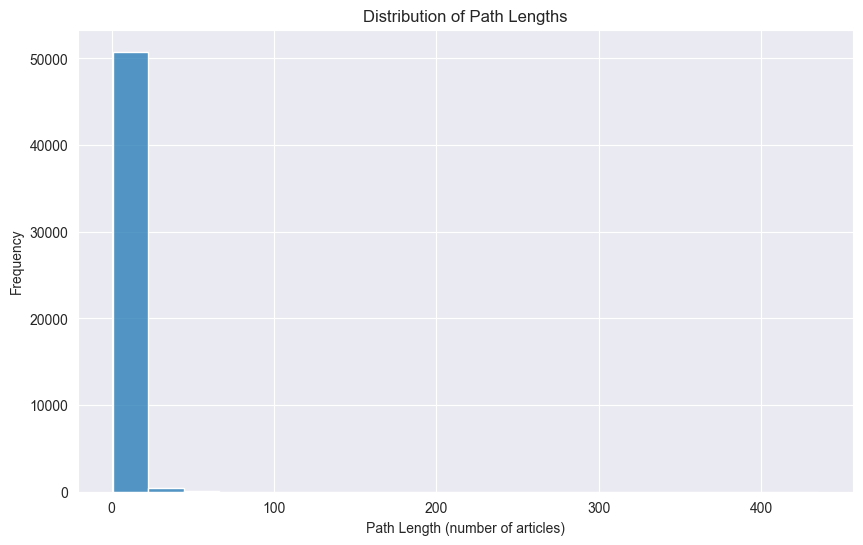

In [11]:
print("--- About finished paths ---")

plt.figure(figsize=(10, 6))
sns.histplot(paths_finished_df['path_length'], kde=False, bins=20)
plt.title('Distribution of Path Lengths')
plt.xlabel('Path Length (number of articles)')
plt.ylabel('Frequency')
plt.show()

# Pre-computation and Setup

In [12]:
HTML_DIR = "./data/wikispeedia_articles_html/wpcd/wp"

if os.path.exists(HTML_DIR):
    html_proc = HtmlProcessor(HTML_DIR)
    link_position_map = html_proc.precompute_positions(articles_df['article_id'].tolist())
    print("Link positions extraction complete.")
else:
    print("HTML Directory not found. Link position feature will be filled with defaults (1.0).")
    link_position_map = {}

extractor = FeatureExtractor()

article_id_to_index = {
    article_id: index 
    for index, article_id in enumerate(articles_df['article_id'])
}

article_id_to_name = pd.Series(
    articles_df.article_name.values, 
    index=articles_df.article_id
).to_dict()

article_name_to_id = pd.Series(
    articles_df.article_id.values,
    index=articles_df.article_name
).to_dict()

links_map = links_df.groupby('source')['target'].apply(list).to_dict()
pagerank_map, out_degree_map = extractor.create_topology_maps(links_df)

embedding_map = {}
for article_id in tqdm(articles_df['article_id'], desc="Generating Embeddings"):
    article_name = article_id_to_name.get(article_id)
    if article_name:
        text = get_article_text(article_name)
        embedding_map[article_id] = extractor.get_text_embedding(text, strategy='first_para')
    else:
        embedding_map[article_id] = np.zeros(EMBEDDING_DIM)

print("Finished.")

Indexing HTML files in ./data/wikispeedia_articles_html/wpcd/wp...
Found 5462 HTML files.
Extracting link positions from HTML...


Parsing HTML: 100%|██████████| 4604/4604 [00:32<00:00, 140.98it/s]


Link positions extraction complete.
Building graph for PageRank and Out-Degree...
Calculating PageRank...
Calculating Out-Degree...
Graph feature maps created.


Generating Embeddings:   0%|          | 0/4604 [00:00<?, ?it/s]

Loading SentenceTransformer model: all-MiniLM-L6-v2...
Model loaded successfully.


Generating Embeddings: 100%|██████████| 4604/4604 [00:40<00:00, 113.94it/s]

Finished.



Data Pipeline: Creating the Feature Dataset

In [13]:
def create_feature_dataset(
    paths_subset_df, 
    links_map, 
    embedding_map, 
    dist_matrix, 
    article_id_to_index, 
    pagerank_map, 
    out_degree_map, 
    link_position_map,
    extractor
):
    X_features = []
    y_labels = []
    query_groups = []
    
    for row in tqdm(paths_subset_df.itertuples(), total=len(paths_subset_df), desc="Processing Paths"):
        path_articles = row.path.split(';')
        goal_id = path_articles[-1]
        
        for i in range(len(path_articles) - 1):
            source_id = path_articles[i]
            positive_target_id = path_articles[i+1]

            query_id = f"{row.Index}_{i}"

            all_candidates = links_map.get(source_id, [])
            if not all_candidates:
                continue 

            current_page_positions = link_position_map.get(source_id, {})

            emb_source = embedding_map.get(source_id, np.zeros(384))
            emb_goal = embedding_map.get(goal_id, np.zeros(384))
            source_idx = article_id_to_index.get(source_id, -1)
            goal_idx = article_id_to_index.get(goal_id, -1)
            
            if source_idx == -1 or goal_idx == -1:
                continue
                
            for candidate_id in all_candidates:
                if candidate_id not in article_id_to_index:
                    continue
                is_positive = 1 if (candidate_id == positive_target_id) else 0
                emb_candidate = embedding_map.get(candidate_id, np.zeros(384))
                candidate_idx = article_id_to_index.get(candidate_id, -1)
                sem_features = extractor.get_semantic_features(emb_source, emb_candidate, emb_goal)
                path_features = extractor.get_shortest_path_features(source_idx, candidate_idx, goal_idx, dist_matrix)
                topo_features = extractor.get_topology_features(candidate_id, pagerank_map, out_degree_map)
                pos_feature = current_page_positions.get(candidate_id, 1.0)

                all_features = {
                    **sem_features, 
                    **path_features, 
                    **topo_features,
                    "link_position": pos_feature 
                }
                
                X_features.append(all_features)
                y_labels.append(is_positive)
                query_groups.append(query_id)

    X_df = pd.DataFrame(X_features)
    y_series = pd.Series(y_labels, name="is_positive")
    query_series = pd.Series(query_groups, name="query_id")
    
    return X_df, y_series, query_series

## Splitting Data and Running the Pipeline

In [14]:
train_paths_df, val_paths_df = train_test_split(
    paths_finished_df, 
    test_size=0.2, 
    random_state=42
)

print(f"Training paths: {len(train_paths_df)}")
print(f"Validation paths: {len(val_paths_df)}")

print("\nGenerating training data...")
X_train_df, y_train, q_train = create_feature_dataset(
    train_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, 
    link_position_map,
    extractor
)

print("\nGenerating validation data...")
X_val_df, y_val, q_val = create_feature_dataset(
    val_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, 
    link_position_map,
    extractor
)

print("\n--- Feature Dataset Shapes ---")
print(f"X_train: {X_train_df.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val_df.shape}, y_val: {y_val.shape}")

print("\n--- Example Features ---")
display(X_train_df.head())

print("\n--- Target Distribution (Train) ---")
print(y_train.value_counts(normalize=True))

Training paths: 41054
Validation paths: 10264

Generating training data...


Processing Paths: 100%|██████████| 41054/41054 [48:05<00:00, 14.23it/s]  



Generating validation data...


Processing Paths: 100%|██████████| 10264/10264 [12:06<00:00, 14.12it/s]



--- Feature Dataset Shapes ---
X_train: (14057674, 8), y_train: (14057674,)
X_val: (3514330, 8), y_val: (3514330,)

--- Example Features ---


,sim_source_candidate,sim_candidate_goal,dist_source_goal,dist_candidate_goal,is_closer,pagerank,out_degree,link_position
0,1.0,1.0,3.0,2.0,1,0.002362,93.0,0.567568
1,1.0,1.0,3.0,3.0,0,0.000485,21.0,0.324324
2,1.0,1.0,3.0,2.0,1,0.002883,29.0,0.135135
3,1.0,1.0,3.0,3.0,0,0.001169,37.0,0.405405
4,1.0,1.0,3.0,3.0,0,0.001214,21.0,0.432432



--- Target Distribution (Train) ---
is_positive
0    0.985248
1    0.014752
Name: proportion, dtype: float64


## Logistic regression (P2 Milestone PoC) - model training

In [15]:
X_train_df.replace([np.inf, -np.inf], 1000, inplace=True)
X_val_df.replace([np.inf, -np.inf], 1000, inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)

print("Training Proof of Concept model (Logistic Regression)...")
model_poc = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_poc.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'coef': model_poc.coef_[0]
}).sort_values('coef', ascending=False)

print("\n--- Feature Importance (Model Coefficients) ---")
display(feature_importance)

Training Proof of Concept model (Logistic Regression)...

--- Feature Importance (Model Coefficients) ---


,feature,coef
2,dist_source_goal,3.435754
5,pagerank,0.280567
4,is_closer,0.188782
0,sim_source_candidate,0.000000
1,sim_candidate_goal,0.000000
6,out_degree,-0.229010
7,link_position,-0.461030
3,dist_candidate_goal,-6.780618


## Logistic regression (P2 Milestone PoC) - evaluation

In [16]:
print("Calculating Mean Reciprocal Rank (MRR) on validation set...")

mrr_score = calculate_mrr(
    model=model_poc,
    X_val=X_val_scaled,
    y_val=y_val,
    query_groups=q_val
)

print("\n" + "="*30)
print(f"   Mean Reciprocal Rank (MRR): {mrr_score:.4f}")
print("="*30)

Calculating Mean Reciprocal Rank (MRR) on validation set...

   Mean Reciprocal Rank (MRR): 0.4736


# Heuristic Approach
Applying the heuristic that combines semantic similarity and hub-seeking behavior

$$
\text{Score}(c)
=
\alpha \cdot \cos(\mathbf{v}_c, \mathbf{v}_g)
\;+\;
(1 - \alpha) \cdot 
\frac{\text{outdeg}(c)}{\max_{c'} \text{outdeg}(c')}
$$

- c = candidate next article  
- g = goal article  
- $v_c$ = embedding vector of the candidate article  
- $v_g$ = embedding vector of the goal article  
- $cos(v_c, v_g)$ = cosine similarity between candidate and goal  
- $outdeg(c)$ = number of outgoing links of candidate (hub measure)  
- $max_{c'} {outdeg}(c')$ = maximum outdegree among all candidates (used to normalize)  
- $\alpha$ in [0,1] = controls trade-off between semantic similarity and hub-seeking  
  - Early in the game → larger $\alpha$ for hub-seeking  
  - Later in the game → smaller $\alpha$ to emphasize semantic closeness

In [17]:
# formatted paths_finished df to apply the heuristic to

formatted_paths_finished_df = expand_paths_to_steps(paths_finished_df)

display(formatted_paths_finished_df)

,step_id,game_id,current_article,next_article,goal_article,path_length,step_number
0,0,0,14th_century,15th_century,African_slave_trade,9,1
1,1,0,15th_century,16th_century,African_slave_trade,9,2
2,2,0,16th_century,Pacific_Ocean,African_slave_trade,9,3
3,3,0,Pacific_Ocean,Atlantic_Ocean,African_slave_trade,9,4
4,4,0,Atlantic_Ocean,Accra,African_slave_trade,9,5
...,...,...,...,...,...,...,...
244148,244148,51315,France,United_States,U.S._Open_(tennis),7,4
244149,244149,51315,United_States,Tennis,U.S._Open_(tennis),7,5
244150,244150,51316,"Yarralumla,_Australian_Capital_Territory",Australia,Abraham_Lincoln,4,1
244151,244151,51316,Australia,United_States,Abraham_Lincoln,4,2


In [18]:
# Loop through formatted_paths_finished_df and calculate heuristic

selected_ids = set()
ranks = []

for _ in range(1000):

    # randomly choose an index that is unique
    while True:
        i = random.randint(0, len(formatted_paths_finished_df) - 1)
        if i not in selected_ids:
            selected_ids.add(i)
            break

    row = formatted_paths_finished_df.iloc[i]
    current_article_id = row["current_article"]
    goal_article_id = row["goal_article"]
    next_article_id = row["next_article"]
    path_length = row["path_length"]
    step_number = row["step_number"]
    alpha = step_number / path_length

    rank = compute_mrr_next_link(current_article_id, goal_article_id, next_article_id, links_map, embedding_map, articles_df, alpha=alpha)

    ranks.append(rank)

mrr = sum(ranks) / len(ranks)
print(f"Mean Reciprocal Rank (MRR): {mrr:.4f}")


Mean Reciprocal Rank (MRR): 0.1776


# Graph Neural Network Approach
Applying a Graph Neural Network (GraphSAGE) to learn contextualized node embeddings that capture both semantic content and local graph topology.

$$
\mathbf{h}_i = \sigma \left( \mathbf{W} \cdot \text{AGG} \left( \{ \mathbf{x}_i \} \cup \{ \mathbf{x}_j, \forall j \in \mathcal{N}(i) \} \right) \right)
$$

$$
\text{Score}(c) = \text{MLP} \left( \mathbf{h}_s \;\|\; \mathbf{h}_c \;\|\; \mathbf{h}_g \right)
$$

- $s, c, g$ = source (current), candidate, and goal articles
- $\mathbf{x}_i$ = initial SBERT embedding of article $i$ (semantic features)
- $\mathbf{h}_i$ = learned GNN embedding of article $i$ (contextualized features)
- $\mathcal{N}(i)$ = set of immediate neighbors of article $i$ in the graph
- $\text{AGG}$ = aggregation function (e.g., mean) combining neighbor information
- $\|$ = concatenation operation
- $\text{MLP}$ = Multi-Layer Perceptron (neural network) that outputs the likelihood of clicking the link
- **Intuition**: Unlike the heuristic, the GNN learns the optimal non-linear combination of semantic similarity ($\mathbf{x}$) and graph structure ($\mathcal{N}$) directly from historical human paths.

### Training Loop

In [24]:
# Device usage
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Running on Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Running on CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Running on cpu")

# Learning parameters
BATCH_SIZE = 2048
NUM_EPOCHS = 10
LR = 0.001
NEG_SAMPLES = 5

print("--- PREPARING GNN DATA ---")
pyg_data, article_id_to_idx = create_pyg_graph(articles_df, links_df, embedding_map)
pyg_data = pyg_data.to(DEVICE)

train_dataset = prepare_all_training_data(train_paths_df, article_id_to_idx, links_map, dist_matrix, neg_samples_ratio=NEG_SAMPLES)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

def train_and_analyze(model_type, epochs=10):
    print(f"\n{'='*40}")
    print(f"TRAINING MODEL: {model_type}")
    print(f"{'='*40}")
    
    model = NavigationGNN(in_channels=384, hidden_channels=128, model_type=model_type).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = torch.nn.BCEWithLogitsLoss()
    
    history = {'loss': [], 'mrr': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            src, cand, goal, dists, labels = batch
            src, cand, goal, dists, labels = src.to(DEVICE), cand.to(DEVICE), goal.to(DEVICE), dists.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            scores = model(pyg_data.x, pyg_data.edge_index, src, cand, goal, dists).squeeze()
            loss = criterion(scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)
        
        val_mrr = evaluate_gnn_mrr(model, pyg_data, val_paths_df, article_id_to_idx, links_map, dist_matrix, DEVICE, sample_size=500)
        history['mrr'].append(val_mrr)
        print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Val MRR {val_mrr:.4f}")
        
    print(f"\n🔍 Running Detailed Error Analysis for {model_type}...")
    analysis_df = run_detailed_error_analysis(model, pyg_data, val_paths_df, article_id_to_idx, links_map, dist_matrix, DEVICE)
    plot_error_analysis(analysis_df, title_prefix=f"Model {model_type}")
    return history, model, analysis_df['mrr'].mean()

Running on Apple MPS
--- PREPARING GNN DATA ---
Building PyTorch Geometric Graph...
Pre-computing tensors WITH DISTANCE (Neg Samples: 5)...


Prep Data: 100%|██████████| 41054/41054 [00:02<00:00, 17130.30it/s]


### Plots


--- EXPERIMENT 1: GraphSAGE ---

TRAINING MODEL: SAGE


Epoch 1: Loss 0.3712 | Val MRR 0.4743


Epoch 2: Loss 0.3595 | Val MRR 0.4695


Epoch 3: Loss 0.3565 | Val MRR 0.4816


Epoch 4: Loss 0.3548 | Val MRR 0.4680


...

Epoch 7: Loss 0.3521 | Val MRR 0.4799


Epoch 8: Loss 0.3518 | Val MRR 0.4751


Epoch 9: Loss 0.3514 | Val MRR 0.4620


Epoch 10: Loss 0.3510 | Val MRR 0.4782

🔍 Running Detailed Error Analysis for SAGE...


Error Analysis: 100%|██████████| 1000/1000 [00:16<00:00, 60.59it/s]


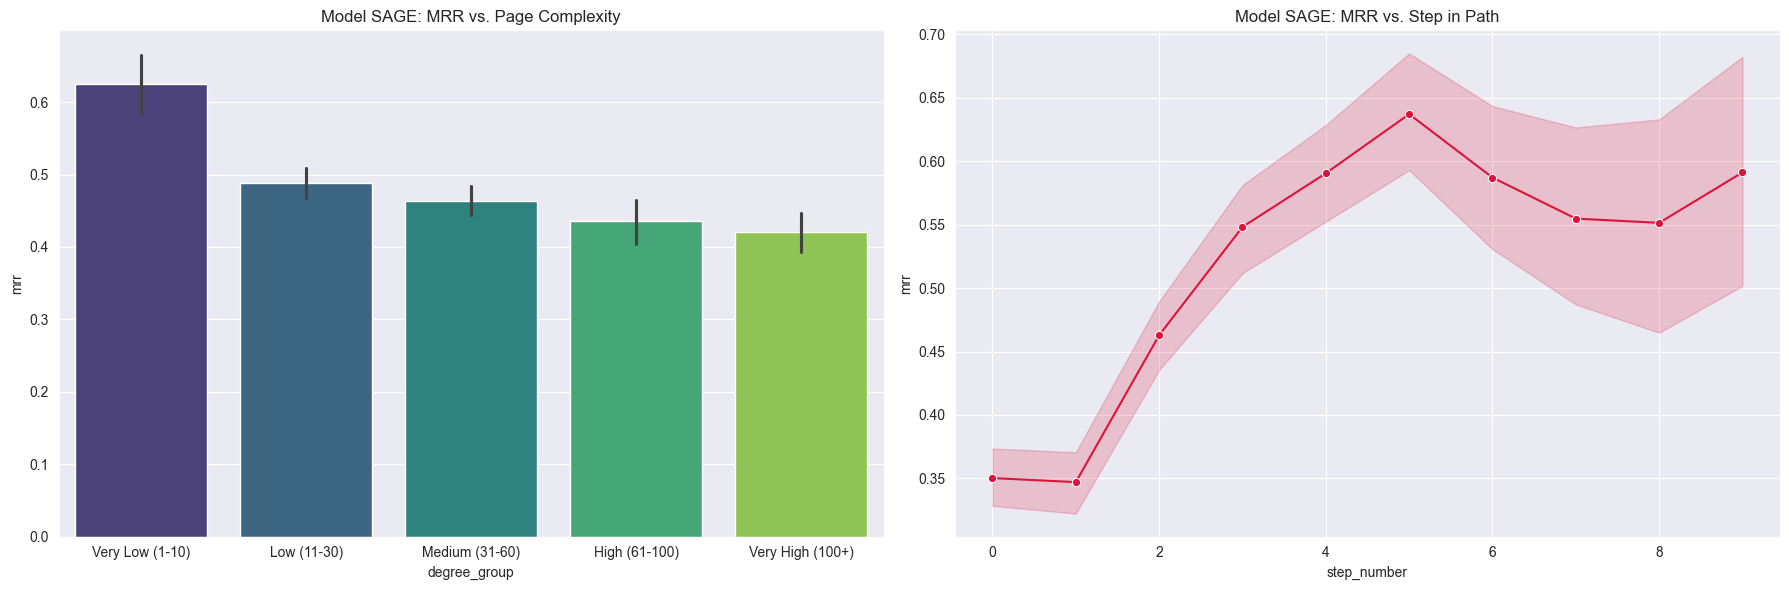


--- EXPERIMENT 2: GATv2 ---

TRAINING MODEL: GAT


Epoch 1: Loss 0.3775 | Val MRR 0.4755


Epoch 2: Loss 0.3566 | Val MRR 0.4525


Epoch 3: Loss 0.3542 | Val MRR 0.4746


Epoch 4: Loss 0.3529 | Val MRR 0.4865


...

Epoch 7: Loss 0.3507 | Val MRR 0.4910


Epoch 8: Loss 0.3503 | Val MRR 0.4874


Epoch 9: Loss 0.3499 | Val MRR 0.4645


Epoch 10: Loss 0.3497 | Val MRR 0.4872

🔍 Running Detailed Error Analysis for GAT...


Error Analysis: 100%|██████████| 1000/1000 [00:16<00:00, 61.51it/s]


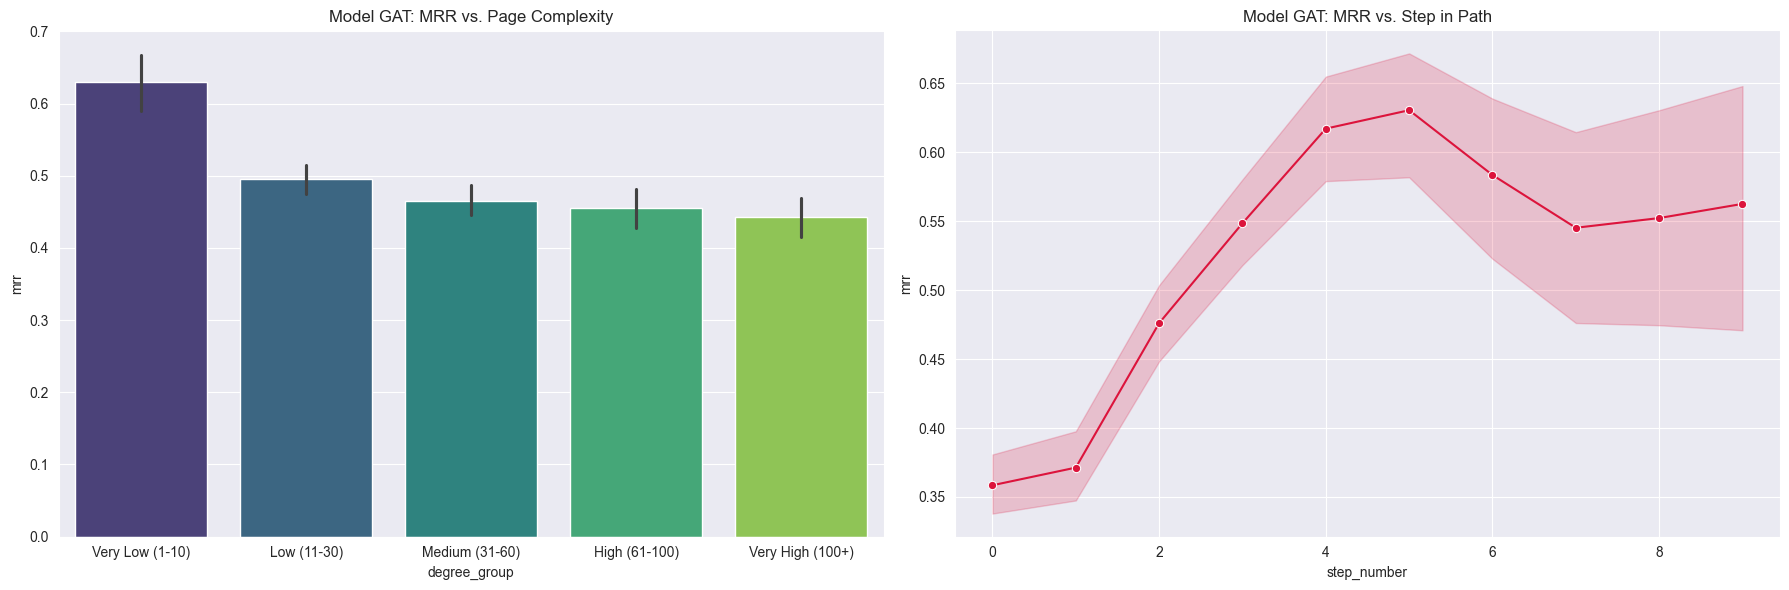

In [25]:
print("\n--- EXPERIMENT 1: GraphSAGE ---")
hist_sage, model_sage, final_mrr_sage = train_and_analyze("SAGE", epochs=NUM_EPOCHS)

print("\n--- EXPERIMENT 2: GATv2 ---")
hist_gat, model_gat, final_mrr_gat = train_and_analyze("GAT", epochs=NUM_EPOCHS)

# Final Comparison


--- FINAL COMPARISON ---


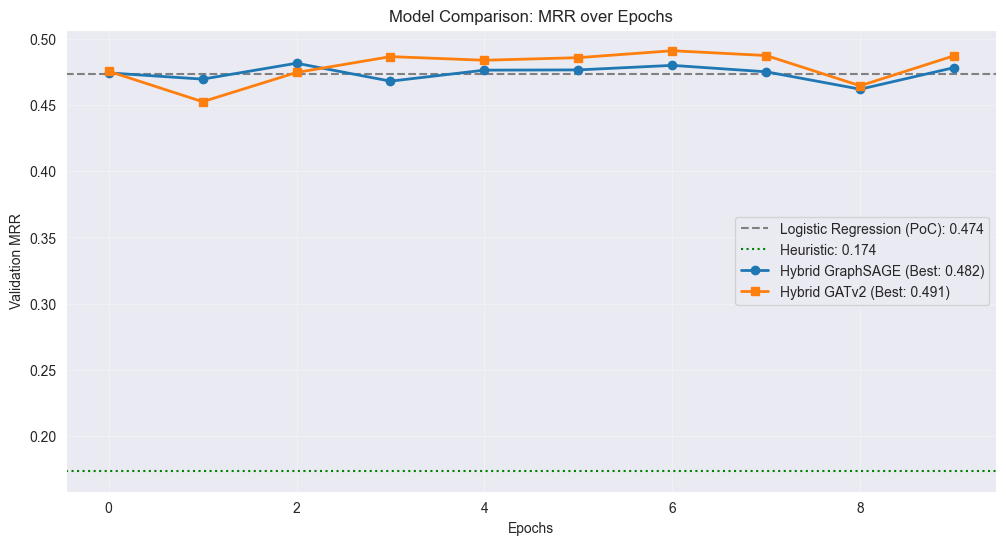

In [26]:
print("\n--- FINAL COMPARISON ---")
plt.figure(figsize=(12, 6))
     
lr_mrr = 0.4736
heuristic_mrr = 0.1739 

plt.axhline(y=lr_mrr, color='gray', linestyle='--', label=f'Logistic Regression (PoC): {lr_mrr:.3f}')
plt.axhline(y=heuristic_mrr, color='green', linestyle=':', label=f'Heuristic: {heuristic_mrr:.3f}')

plt.plot(hist_sage['mrr'], label=f'Hybrid GraphSAGE (Best: {max(hist_sage["mrr"]):.3f})', marker='o', linewidth=2)
plt.plot(hist_gat['mrr'], label=f'Hybrid GATv2 (Best: {max(hist_gat["mrr"]):.3f})', marker='s', linewidth=2)

plt.title('Model Comparison: MRR over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation MRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()